# Notebook 2: NLP Unstructured PDF Processing & Knowledge Extraction
**Topic:** NLP-Enhanced Knowledge Transfer for Energy Consumption Prediction in Data-Scarce Electric Vehicles

This notebook covers:
- Extracting text from EV PDF manuals
- Text cleaning and preprocessing
- Keyword & energy-related knowledge extraction
- TF-IDF feature extraction
- BERT sentence embeddings
- Saving NLP artifacts for Notebook 3

## Step 1: Install Required Libraries

In [1]:
!pip install pdfplumber nltk sentence-transformers scikit-learn pandas numpy matplotlib seaborn wordcloud joblib

## Step 2: Import Libraries

In [2]:
import os
import re
import json
import joblib
import warnings
import pdfplumber
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud

from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')

# Download NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

print('All libraries loaded!')


All libraries loaded!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SUNILRAJ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SUNILRAJ\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\SUNILRAJ\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\SUNILRAJ\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


## Step 3: Load and Extract Text from PDFs

In [3]:
# -----------------------------------------------
# 3.1 - Define PDF folder path
# -----------------------------------------------

pdf_folder = '../data/unstructured'
pdf_files  = [f for f in os.listdir(pdf_folder) if f.endswith('.pdf')]

print(f'Found {len(pdf_files)} PDF files:')
for f in pdf_files:
    print(f'  - {f}')

Found 7 PDF files:
  - chevrolet-bolt-euv.pdf
  - Ford_Mustang_Mach.pdf
  - IONIQ_5.pdf
  - mercedes-eqs-saloon.pdf
  - nissian_leaf.pdf
  - punch-ev.pdf
  - tesla_model_3.pdf


In [4]:
# -----------------------------------------------
# 3.2 - Extract text from all PDFs (using PyMuPDF - memory efficient)
# -----------------------------------------------

import fitz  # PyMuPDF

def extract_text_from_pdf(filepath):
    """Extract text from PDF using PyMuPDF - memory efficient."""
    full_text = []
    try:
        doc = fitz.open(filepath)
        for page_num in range(len(doc)):
            page = doc.load_page(page_num)
            text = page.get_text("text")
            if text.strip():
                full_text.append(text)
            page = None  # release page from memory immediately
        doc.close()
        return ' '.join(full_text)
    except Exception as e:
        print(f'Error reading {filepath}: {e}')
        return ''


pdf_texts = {}
for pdf_file in pdf_files:
    filepath = os.path.join(pdf_folder, pdf_file)
    text     = extract_text_from_pdf(filepath)
    pdf_texts[pdf_file] = text
    print(f'{pdf_file}: {len(text)} characters extracted')

print(f'\nTotal PDFs processed: {len(pdf_texts)}')

chevrolet-bolt-euv.pdf: 716699 characters extracted
Ford_Mustang_Mach.pdf: 867764 characters extracted
IONIQ_5.pdf: 932945 characters extracted
mercedes-eqs-saloon.pdf: 1607644 characters extracted
nissian_leaf.pdf: 960932 characters extracted
punch-ev.pdf: 379160 characters extracted
tesla_model_3.pdf: 901929 characters extracted

Total PDFs processed: 7


In [5]:
# -----------------------------------------------
# 3.3 - Combine all texts + create a dataframe
# -----------------------------------------------

# Combined full corpus
all_text = ' '.join(pdf_texts.values())
print(f'Total corpus size: {len(all_text)} characters')

# Per-document dataframe
doc_df = pd.DataFrame([
    {'filename': k, 'raw_text': v, 'char_count': len(v)}
    for k, v in pdf_texts.items()
])
doc_df.head()

Total corpus size: 6367079 characters


,filename,raw_text,char_count
0,chevrolet-bolt-euv.pdf,Contents\nIntroduction . . . . . . . . . . . ....,716699
1,Ford_Mustang_Mach.pdf,FORD MUSTANG MACH-E\nOwner's Manual 2023\n The...,867764
2,IONIQ_5.pdf,All information in this Owner’s Manual is curr...,932945
3,mercedes-eqs-saloon.pdf,EQS\nOwner's Manual +\nohne\n Did you know?\nI...,1607644
4,nissian_leaf.pdf,2023 LEAF\n®\nOWNER’S MANUAL \nand MAINTENANC...,960932


## Step 4: Text Cleaning & Preprocessing

In [6]:
# -----------------------------------------------
# 4.1 - Clean text function
# -----------------------------------------------

lemmatizer  = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text):
    """Full text cleaning pipeline."""
    # Lowercase
    text = text.lower()
    # Remove special characters and numbers (keep letters and spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and short words
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


# Clean each document
doc_df['clean_text'] = doc_df['raw_text'].apply(clean_text)

# Combined clean corpus
clean_corpus = ' '.join(doc_df['clean_text'].tolist())

print('Text cleaning done!')
print(f'Clean corpus size: {len(clean_corpus)} characters')
print('\nSample cleaned text (first 500 chars):')
print(clean_corpus[:500])

Text cleaning done!
Clean corpus size: 4314458 characters

Sample cleaned text (first 500 chars):
content introduction key door window seat restraint storage instrument control lighting infotainment system climate control driving operating vehicle care service maintenance technical data customer information reporting safety defect onstar connected service index introduction name logo emblem slogan vehicle model name vehicle body design appearing manual including limited logo chevrolet chevrolet emblem bolt trademark service mark general motor llc subsidiary affiliate licensors vehicle first 


In [7]:
# -----------------------------------------------
# 4.2 - Sentence tokenization (for embeddings)
# -----------------------------------------------

all_sentences = []
for doc_name, raw_text in pdf_texts.items():
    sentences = sent_tokenize(raw_text)
    # Keep sentences with 10+ words (meaningful)
    sentences = [s.strip() for s in sentences if len(s.split()) >= 10]
    for sent in sentences:
        all_sentences.append({'doc': doc_name, 'sentence': sent})

sentence_df = pd.DataFrame(all_sentences)
print(f'Total meaningful sentences extracted: {len(sentence_df)}')
sentence_df.head()

Total meaningful sentences extracted: 41647


,doc,sentence
0,chevrolet-bolt-euv.pdf,"327\nIntroduction\nThe names, logos, emblems, ..."
1,chevrolet-bolt-euv.pdf,"For vehicles first sold in Canada, substitute\..."
2,chevrolet-bolt-euv.pdf,This manual describes features that may or\nma...
3,chevrolet-bolt-euv.pdf,Refer to the purchase documentation\nrelating ...
4,chevrolet-bolt-euv.pdf,Canadian Vehicle Owners\nA French language man...


## Step 5: Energy Knowledge Extraction

In [8]:
# -----------------------------------------------
# 5.1 - Extract energy-relevant sentences using keywords
# -----------------------------------------------

# Keywords related to energy consumption factors
energy_keywords = [
    'energy', 'battery', 'consumption', 'range', 'efficiency',
    'charge', 'charging', 'discharge', 'temperature', 'cold', 'heat',
    'speed', 'acceleration', 'deceleration', 'regenerative',
    'driving mode', 'eco', 'sport', 'highway', 'city',
    'climate', 'hvac', 'heater', 'air conditioning', 'wind',
    'slope', 'hill', 'gradient', 'weight', 'load',
    'tire', 'pressure', 'rolling', 'aerodynamic', 'drag'
]

def is_energy_relevant(sentence):
    sentence_lower = sentence.lower()
    return any(kw in sentence_lower for kw in energy_keywords)

sentence_df['is_energy_relevant'] = sentence_df['sentence'].apply(is_energy_relevant)
energy_sentences_df = sentence_df[sentence_df['is_energy_relevant'] == True].copy()

print(f'Total sentences: {len(sentence_df)}')
print(f'Energy-relevant sentences: {len(energy_sentences_df)}')
print(f'Relevance ratio: {len(energy_sentences_df)/len(sentence_df)*100:.1f}%')

print('\nSample energy-relevant sentences:')
for sent in energy_sentences_df['sentence'].head(5).tolist():
    print(f'  → {sent[:150]}')

Total sentences: 41647
Energy-relevant sentences: 14056
Relevance ratio: 33.8%

Sample energy-relevant sentences:
  → u : Air Conditioning System
G : Air Conditioning Refrigerant Oil
9 : Airbag Readiness Light
!
  → : Antilock Brake System (ABS)
$ : Brake System Warning Light
9 : Dispose of Used Components Properly
P : Do Not Apply High Pressure Water
[ : Energy U
  → Charging Status Feedback 0 232
Indicator Light and Solar Sensor (ILSS).
  → 6
Keys, Doors, and Windows
Keys, Doors, and
Windows
Keys and Locks
Keys .
  → They could
operate the power windows or other
controls or make the vehicle move.


In [9]:
# -----------------------------------------------
# 5.2 - Extract structured knowledge rules
# -----------------------------------------------

# Pattern-based rule extraction
knowledge_rules = []

rule_patterns = [
    # Temperature rules
    (r'.{0,100}(cold|low temperature|freezing|winter).{0,100}(battery|range|efficiency).{0,100}',
     'temperature_cold', 'Cold temperature reduces battery efficiency/range'),
    
    (r'.{0,100}(high temperature|hot|heat|summer).{0,100}(battery|range|efficiency).{0,100}',
     'temperature_hot', 'High temperature affects battery performance'),
    
    # Speed rules
    (r'.{0,100}(high speed|highway|faster).{0,100}(energy|consumption|range).{0,100}',
     'speed_high', 'Higher speed increases energy consumption'),
    
    # Driving mode rules
    (r'.{0,100}(eco mode|economy).{0,100}(energy|consumption|efficiency|range).{0,100}',
     'eco_mode', 'Eco mode improves energy efficiency'),
    
    (r'.{0,100}(sport mode).{0,100}(energy|consumption|battery).{0,100}',
     'sport_mode', 'Sport mode increases energy consumption'),
    
    # Charging rules
    (r'.{0,100}(regenerative braking|regen).{0,100}(energy|recover|charge).{0,100}',
     'regenerative', 'Regenerative braking recovers energy'),
    
    # HVAC rules
    (r'.{0,100}(air conditioning|hvac|heater|climate).{0,100}(energy|battery|consumption).{0,100}',
     'hvac', 'HVAC usage increases energy consumption'),
    
    # Slope rules
    (r'.{0,100}(uphill|incline|gradient|slope).{0,100}(energy|battery|consumption).{0,100}',
     'slope_uphill', 'Uphill driving increases energy consumption'),
    
    # Tire rules
    (r'.{0,100}(tire pressure|tyre pressure).{0,100}(range|efficiency|consumption).{0,100}',
     'tire_pressure', 'Tire pressure affects rolling resistance and range'),
]

for doc_name, raw_text in pdf_texts.items():
    text_lower = raw_text.lower()
    for pattern, rule_type, description in rule_patterns:
        matches = re.findall(pattern, text_lower[:50000], re.IGNORECASE | re.DOTALL)
        if matches:
            knowledge_rules.append({
                'source': doc_name,
                'rule_type': rule_type,
                'description': description,
                'match_count': len(matches)
            })

rules_df = pd.DataFrame(knowledge_rules)
if len(rules_df) > 0:
    rules_summary = rules_df.groupby(['rule_type', 'description'])['match_count'].sum().reset_index()
    rules_summary = rules_summary.sort_values('match_count', ascending=False)
    print('Knowledge Rules Extracted:')
    print(rules_summary.to_string(index=False))
else:
    print('No rules matched — try adjusting keywords or patterns.')

Knowledge Rules Extracted:
       rule_type                                        description  match_count
 temperature_hot       High temperature affects battery performance            8
temperature_cold  Cold temperature reduces battery efficiency/range            8
            hvac            HVAC usage increases energy consumption            6
    regenerative               Regenerative braking recovers energy            5
    slope_uphill        Uphill driving increases energy consumption            1
   tire_pressure Tire pressure affects rolling resistance and range            1


In [10]:
# -----------------------------------------------
# 5.3 - Build knowledge score weights from rules
# -----------------------------------------------

# These weights will be used in Notebook 3 to adjust feature importance
knowledge_weights = {
    'Speed_kmh'            : 0.0,
    'Temperature_C'        : 0.0,
    'Battery_Temperature_C': 0.0,
    'Slope_%'              : 0.0,
    'Driving_Mode'         : 0.0,
    'Tire_Pressure_psi'    : 0.0,
    'Wind_Speed_ms'        : 0.0,
    'Humidity_%'           : 0.0
}

# Map rule types to features and assign weights based on mention frequency
rule_to_feature = {
    'speed_high'     : 'Speed_kmh',
    'temperature_cold': 'Temperature_C',
    'temperature_hot' : 'Battery_Temperature_C',
    'slope_uphill'   : 'Slope_%',
    'eco_mode'       : 'Driving_Mode',
    'sport_mode'     : 'Driving_Mode',
    'tire_pressure'  : 'Tire_Pressure_psi',
    'hvac'           : 'Temperature_C'
}

if len(rules_df) > 0:
    for _, row in rules_summary.iterrows():
        rule_type = row['rule_type']
        count     = row['match_count']
        if rule_type in rule_to_feature:
            feat = rule_to_feature[rule_type]
            knowledge_weights[feat] += count

    # Normalize weights to 0-1 range
    max_val = max(knowledge_weights.values()) if max(knowledge_weights.values()) > 0 else 1
    knowledge_weights = {k: round(v / max_val, 4) for k, v in knowledge_weights.items()}

print('Knowledge-derived Feature Weights:')
for feat, weight in sorted(knowledge_weights.items(), key=lambda x: -x[1]):
    print(f'  {feat:<30}: {weight}')

Knowledge-derived Feature Weights:
  Temperature_C                 : 1.0
  Battery_Temperature_C         : 0.5714
  Slope_%                       : 0.0714
  Tire_Pressure_psi             : 0.0714
  Speed_kmh                     : 0.0
  Driving_Mode                  : 0.0
  Wind_Speed_ms                 : 0.0
  Humidity_%                    : 0.0


## Step 6: TF-IDF Feature Extraction

In [11]:
# -----------------------------------------------
# 6.1 - Fit TF-IDF on energy-relevant sentences
# -----------------------------------------------

energy_texts = energy_sentences_df['sentence'].tolist()

if len(energy_texts) == 0:
    # fallback: use all sentences
    energy_texts = sentence_df['sentence'].tolist()
    print('Using all sentences for TF-IDF (no energy-specific sentences found)')

tfidf_vectorizer = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    min_df=2,
    stop_words='english'
)

tfidf_matrix = tfidf_vectorizer.fit_transform(energy_texts)
tfidf_array  = tfidf_matrix.toarray()

print(f'TF-IDF Matrix shape: {tfidf_array.shape}')
print(f'Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}')

# Top TF-IDF terms
feature_names = tfidf_vectorizer.get_feature_names_out()
mean_tfidf    = tfidf_array.mean(axis=0)
top_terms_idx = mean_tfidf.argsort()[-30:][::-1]
top_terms     = [(feature_names[i], round(mean_tfidf[i], 4)) for i in top_terms_idx]

print('\nTop 30 TF-IDF Terms:')
for term, score in top_terms:
    print(f'  {term:<30}: {score}')

TF-IDF Matrix shape: (14056, 500)
Vocabulary size: 500

Top 30 TF-IDF Terms:
  vehicle                       : 0.0601
  charging                      : 0.045
  speed                         : 0.0341
  battery                       : 0.0334
  tire                          : 0.0325
  charge                        : 0.0307
  driving                       : 0.0221
  pressure                      : 0.0191
  control                       : 0.0169
  use                           : 0.0167
  power                         : 0.0162
  high                          : 0.0156
  tires                         : 0.0155
  time                          : 0.0151
  temperature                   : 0.0144
  information                   : 0.0142
  set                           : 0.0138
  mode                          : 0.0131
  air                           : 0.013
  range                         : 0.013
  display                       : 0.0124
  note                          : 0.0124
  climate               

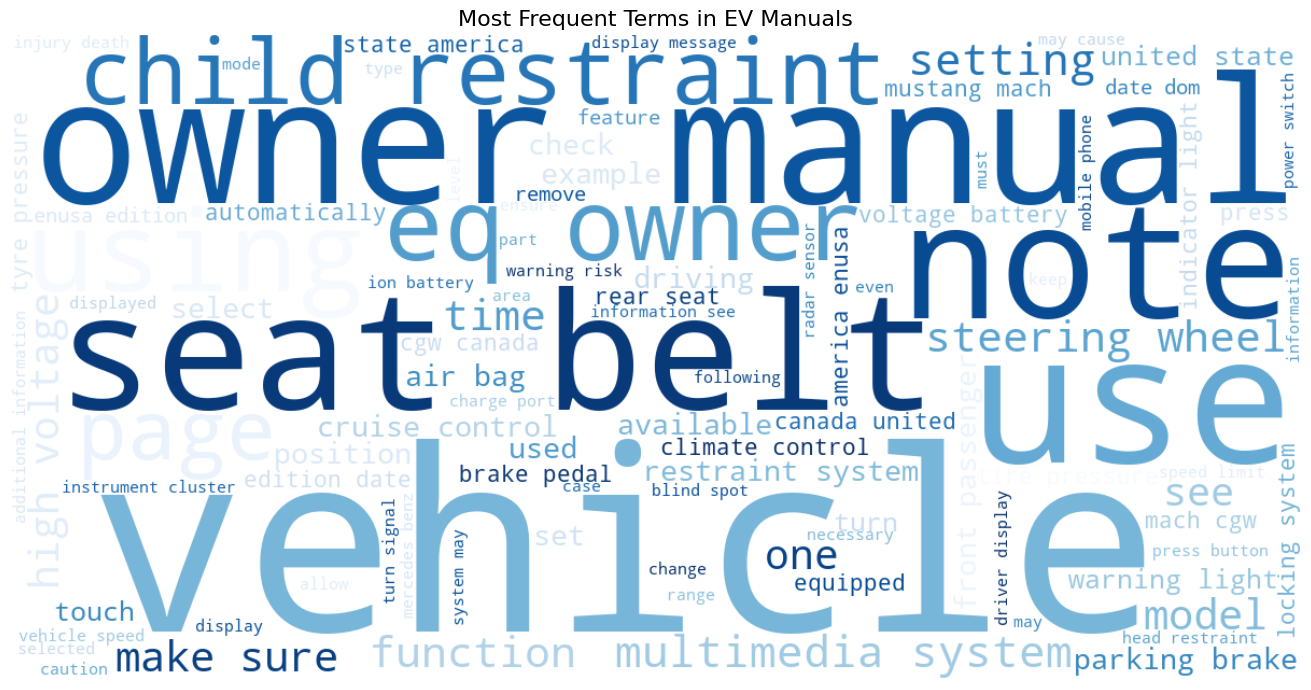

In [12]:
# -----------------------------------------------
# 6.2 - Word Cloud Visualization
# -----------------------------------------------

wordcloud = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='Blues',
    max_words=100
).generate(clean_corpus)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Terms in EV Manuals', fontsize=16)
plt.tight_layout()
plt.savefig('../results/wordcloud.png', dpi=150)
plt.show()

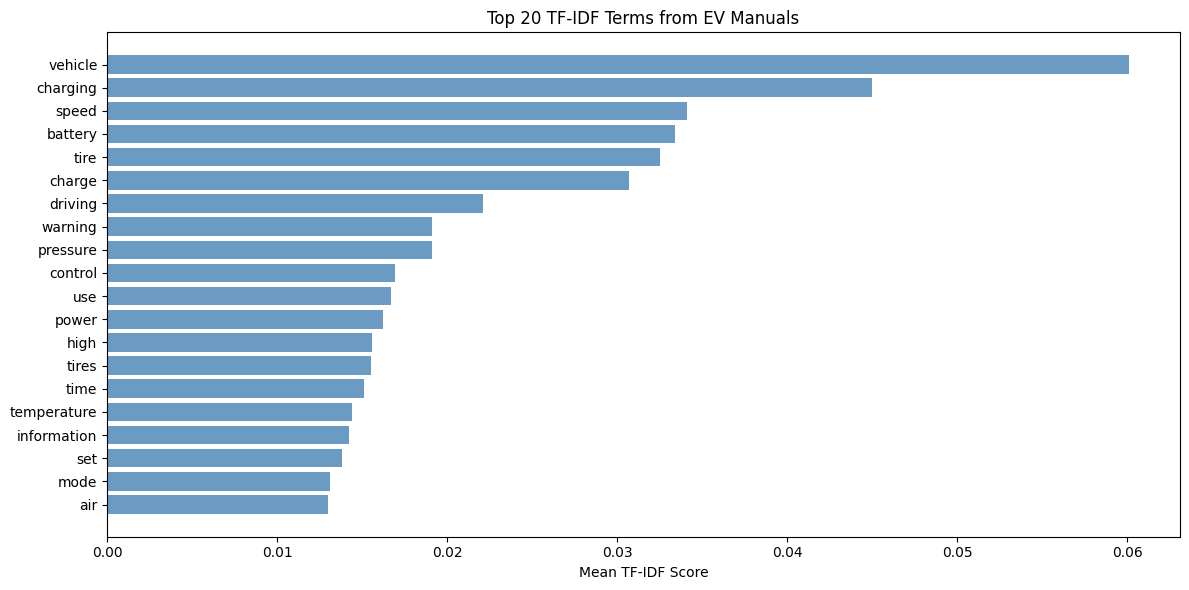

In [13]:
# -----------------------------------------------
# 6.3 - Top Terms Bar Chart
# -----------------------------------------------

terms, scores = zip(*top_terms[:20])
plt.figure(figsize=(12, 6))
plt.barh(terms[::-1], scores[::-1], color='steelblue', alpha=0.8)
plt.title('Top 20 TF-IDF Terms from EV Manuals')
plt.xlabel('Mean TF-IDF Score')
plt.tight_layout()
plt.savefig('../results/tfidf_top_terms.png', dpi=150)
plt.show()

## Step 7: BERT Sentence Embeddings

In [14]:
# -----------------------------------------------
# 7.1 - Generate sentence embeddings using BERT
# -----------------------------------------------

print('Loading BERT sentence transformer model...')
bert_model = SentenceTransformer('all-MiniLM-L6-v2')  # lightweight, fast
print('Model loaded!')

# Use energy-relevant sentences only (limit to 1000 for speed)
sentences_to_embed = energy_sentences_df['sentence'].tolist()[:1000]
if len(sentences_to_embed) == 0:
    sentences_to_embed = sentence_df['sentence'].tolist()[:1000]

print(f'Generating embeddings for {len(sentences_to_embed)} sentences...')
sentence_embeddings = bert_model.encode(
    sentences_to_embed,
    show_progress_bar=True,
    batch_size=32
)

print(f'Embeddings shape: {sentence_embeddings.shape}')
print('Each sentence = 384-dimensional vector')

Loading BERT sentence transformer model...
Model loaded!
Generating embeddings for 1000 sentences...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embeddings shape: (1000, 384)
Each sentence = 384-dimensional vector


In [15]:
# -----------------------------------------------
# 7.2 - Create a domain knowledge vector
# Summarize all EV knowledge into ONE vector
# -----------------------------------------------

# Mean of all sentence embeddings = domain knowledge representation
domain_knowledge_vector = np.mean(sentence_embeddings, axis=0)

print(f'Domain Knowledge Vector shape: {domain_knowledge_vector.shape}')
print('This vector represents the overall EV energy knowledge from manuals.')
print('\nFirst 10 values:', domain_knowledge_vector[:10].round(4))

Domain Knowledge Vector shape: (384,)
This vector represents the overall EV energy knowledge from manuals.

First 10 values: [ 0.0031  0.0234 -0.009   0.0206  0.0196  0.0118 -0.001  -0.      0.0081
  0.0049]


In [16]:
# -----------------------------------------------
# 7.3 - Query most relevant sentences for each feature
# -----------------------------------------------

feature_queries = {
    'Speed_kmh'             : 'energy consumption at high speed highway driving',
    'Temperature_C'         : 'battery range affected by cold hot temperature weather',
    'Slope_%'               : 'energy consumption uphill downhill slope gradient',
    'Driving_Mode'          : 'eco sport driving mode energy efficiency',
    'Battery_State_%'       : 'battery state of charge level efficiency',
    'Tire_Pressure_psi'     : 'tire pressure rolling resistance energy efficiency',
    'Wind_Speed_ms'         : 'wind resistance aerodynamic drag energy',
    'Traffic_Condition'     : 'stop and go traffic energy consumption'
}

feature_relevant_sentences = {}

for feature, query in feature_queries.items():
    query_embedding  = bert_model.encode([query])
    similarities     = cosine_similarity(query_embedding, sentence_embeddings)[0]
    top_idx          = similarities.argsort()[-3:][::-1]
    top_sents        = [sentences_to_embed[i] for i in top_idx]
    top_scores       = [round(float(similarities[i]), 4) for i in top_idx]
    feature_relevant_sentences[feature] = [
        {'sentence': s, 'score': sc} for s, sc in zip(top_sents, top_scores)
    ]

print('Top relevant sentences per feature:')
for feat, items in feature_relevant_sentences.items():
    print(f'\n  [{feat}]')
    for item in items:
        print(f'    Score {item["score"]}: {item["sentence"][:100]}...')

Top relevant sentences per feature:

  [Speed_kmh]
    Score 0.5979: Driving for Better Energy
Efficiency
Use the following tips to help maximize
energy efficiency and r...
    Score 0.5594: 172
Driving and Operating
Terrain and Vehicle Speed
Higher speeds and grade changes use more
energy ...
    Score 0.4813: This number reflects only the
approximate average electrical energy
economy that the vehicle has rig...

  [Temperature_C]
    Score 0.6305: Outside Temperature includes the effect
that hot or cold ambient temperature has
on the battery perf...
    Score 0.6112: Use the Enhanced Battery Gauge on the
Instrument Cluster to view the effect of
climate control setti...
    Score 0.5841: It is recommended that
the vehicle be plugged in when
temperatures are below 0 °C (32 °F) and
above ...

  [Slope_%]
    Score 0.5539: When going up
steep hills, you might have to step on the
accelerator pedal to maintain the vehicle
s...
    Score 0.4587: When going downhill, you might
have to brake 

## Step 8: Save All NLP Artifacts

In [17]:
os.makedirs('../saved_models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

# Save TF-IDF vectorizer
joblib.dump(tfidf_vectorizer, '../saved_models/tfidf_vectorizer.pkl')
print('TF-IDF vectorizer saved!')

# Save TF-IDF matrix
np.save('../saved_models/tfidf_matrix.npy', tfidf_array)
print('TF-IDF matrix saved!')

# Save sentence embeddings
np.save('../saved_models/sentence_embeddings.npy', sentence_embeddings)
print('Sentence embeddings saved!')

# Save domain knowledge vector (most important for Notebook 3)
np.save('../saved_models/domain_knowledge_vector.npy', domain_knowledge_vector)
print('Domain knowledge vector saved!')

# Save knowledge weights (rules-based)
with open('../saved_models/knowledge_weights.json', 'w') as f:
    json.dump(knowledge_weights, f, indent=2)
print('Knowledge weights saved!')

# Save knowledge rules
with open('../saved_models/knowledge_rules.json', 'w') as f:
    json.dump(feature_relevant_sentences, f, indent=2)
print('Knowledge rules saved!')

# Save energy sentences
energy_sentences_df.to_csv('../results/energy_sentences.csv', index=False)
print('Energy sentences saved!')

# Save top TF-IDF terms
pd.DataFrame(top_terms, columns=['term', 'tfidf_score']).to_csv(
    '../results/tfidf_top_terms.csv', index=False)
print('Top TF-IDF terms saved!')

TF-IDF vectorizer saved!
TF-IDF matrix saved!
Sentence embeddings saved!
Domain knowledge vector saved!
Knowledge weights saved!
Knowledge rules saved!
Energy sentences saved!
Top TF-IDF terms saved!


In [18]:
print('='*55)
print('NOTEBOOK 2 COMPLETE!')
print('='*55)
print(f'PDFs Processed         : {len(pdf_files)}')
print(f'Total Sentences        : {len(sentence_df)}')
print(f'Energy Sentences       : {len(energy_sentences_df)}')
print(f'TF-IDF Features        : {tfidf_array.shape[1]}')
print(f'Embedding Dimensions   : {sentence_embeddings.shape[1]}')
print(f'Knowledge Rules Found  : {len(rules_df)}')
print('\nFiles saved:')
print('  saved_models/tfidf_vectorizer.pkl')
print('  saved_models/tfidf_matrix.npy')
print('  saved_models/sentence_embeddings.npy')
print('  saved_models/domain_knowledge_vector.npy')
print('  saved_models/knowledge_weights.json')
print('  saved_models/knowledge_rules.json')
print('  results/energy_sentences.csv')
print('  results/tfidf_top_terms.csv')
print('\nReady for Notebook 3 (Combined Model)!')

NOTEBOOK 2 COMPLETE!
PDFs Processed         : 7
Total Sentences        : 41647
Energy Sentences       : 14056
TF-IDF Features        : 500
Embedding Dimensions   : 384
Knowledge Rules Found  : 15

Files saved:
  saved_models/tfidf_vectorizer.pkl
  saved_models/tfidf_matrix.npy
  saved_models/sentence_embeddings.npy
  saved_models/domain_knowledge_vector.npy
  saved_models/knowledge_weights.json
  saved_models/knowledge_rules.json
  results/energy_sentences.csv
  results/tfidf_top_terms.csv

Ready for Notebook 3 (Combined Model)!
